<a href="https://colab.research.google.com/github/mohammedfaizal1310-web/AI-Evaluator-/blob/main/BuildingLinearRegressionfromscratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [73]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

In [74]:
print(type(housing))
print(housing.keys())
print(housing.data.shape)
print(housing.target.shape)
print(housing.feature_names)


<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
(20640, 8)
(20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [75]:
x=housing.data
y=housing.target
print("X vlaue:",x.shape)
print("Y vlaue:", y.shape)

X vlaue: (20640, 8)
Y vlaue: (20640,)


In [76]:
print(type(x))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [77]:
x=x.values
y=y.values
print(type(x))
print(type(y))
print(x.shape)
print(y.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(20640, 8)
(20640,)


In [78]:
print(x[0])
print(y[0])

[   8.3252       41.            6.98412698    1.02380952  322.
    2.55555556   37.88       -122.23      ]
4.526


In [79]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [80]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
print(x_train.shape)
print(x_test.shape)
print(x_train[0])
print(x_train.mean())
print(x_train.std())

(16512, 8)
(4128, 8)
[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
 -1.3728112   1.27258656]
-3.8499296343511937e-14
1.0000000000000033


In [81]:
x_train=np.c_[np.ones(x_train.shape[0]),x_train]
x_test=np.c_[np.ones(x_test.shape[0]),x_test]
print(x_train.shape)
print(x_test.shape)

(16512, 9)
(4128, 9)


In [82]:
n=x_train.shape[1]
theta=np.zeros(n)
print(theta)
print(theta.shape)


[0. 0. 0. 0. 0. 0. 0. 0. 0.]
(9,)


In [83]:
def compute_cost(x,y,theta):
    m=len(y)
    predictions=x.dot(theta)
    cost=(1/(2*m))*np.sum(np.square(predictions-y))
    return cost
initail_cost=compute_cost(x_train,y_train,theta)
print(initail_cost)

2.8148711615515656


In [84]:
print(y_train[:5])

[1.03  3.821 1.726 0.934 0.965]


In [85]:
print(x_train.shape)
print(theta.shape)

predictions = x_train.dot(theta)

print(predictions[:5])

(16512, 9)
(9,)
[0. 0. 0. 0. 0.]


In [86]:
print(compute_cost(x_train, y_train, theta))

2.8148711615515656


In [87]:
def gradient_descent(x, y, theta, learning_rate, iterations):

    m = len(y)

    cost_history = []

    for i in range(iterations):

        predictions = x.dot(theta)

        errors = predictions - y

        gradient = (1 / m) * x.T.dot(errors)

        theta = theta - learning_rate * gradient

        cost = compute_cost(x, y, theta)

        cost_history.append(cost)

    return theta, cost_history

In [88]:
learning_rate = 0.01
iterations = 1000

theta, cost_history = gradient_descent(
    x_train,
    y_train,
    theta,
    learning_rate,
    iterations
)

In [89]:
print("Initial Cost:", cost_history[0])
print("Final Cost:", cost_history[-1])

Initial Cost: 2.7649865663007085
Final Cost: 0.27383908868567214


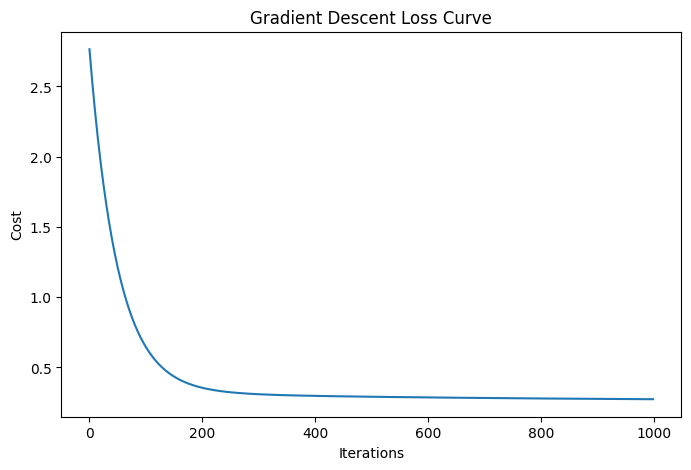

In [90]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.title("Gradient Descent Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.show()

In [93]:
y_pred=x_test.dot(theta)
print("Predicted value",y_pred[:5])
print("Actual value",y_test[:5])

Predicted value [0.88074769 1.65287274 2.50202574 2.76536073 2.35509435]
Actual value [0.477   0.458   5.00001 2.186   2.78   ]


In [94]:
from sklearn.metrics import mean_squared_error , r2_score
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print("RMSE:",rmse)
print("R2:",r2)

RMSE: 0.7531170550506763
R2: 0.5671692517174325


In [96]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

sklearn_pred = lr.predict(x_test)

In [97]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

sk_rmse = np.sqrt(mean_squared_error(y_test, sklearn_pred))
sk_r2 = r2_score(y_test, sklearn_pred)

print("Sklearn RMSE:", sk_rmse)
print("Sklearn R²:", sk_r2)

Sklearn RMSE: 0.7455813830127762
Sklearn R²: 0.575787706032451
